In [1]:
import sys
MODULEPATH="../../"
sys.path.append(MODULEPATH)
sys.path.append('../')

from connectivity.connectivity import trace_connectivity, extract_connection_indices, save_descent_paths
from connectivity.plot_results import plot_results_with_paths, plot_saddle_tree_with_function
from test_schwefel.schwefel_function_nnmodule import Schwefel2D, schwefel_loss, schwefel2D_numpy
from connectivity.connectivity import optimize_lbfgs

from connectivity.saddle_tree_calculations import saddle_tree_calculations
import matplotlib.pyplot as plt
import pandas as pd

In [7]:
critical_points_file = "./critical_points_schwefel.csv"

dataframe = pd.read_csv(critical_points_file)
saddles_df = dataframe[dataframe["type"] == "saddle"]
# minima_df = dataframe[dataframe["type"] == "minimum"]
minima_df = dataframe[dataframe["type"] != "maximum"]

build_schwefel = lambda p: Schwefel2D(*p)

In [8]:
all_results, minima, dataframe, paths = trace_connectivity(saddles_df,
                                                           minima_df,
                                                           dataframe,
                                                           schwefel_loss,
                                                           build_schwefel,
                                                           [],
                                                           return_paths=True)


In [9]:
save_descent_paths(paths)
extract_connection_indices(all_results, dataframe)
saddle_tree_calculations(all_results, minima, dataframe)

Saved 22 connections to results/connectivity_graph.csv
index_map [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19]
Saved node order to results/tree_nodes.csv
Saved tree edges to results/tree_connectivity.csv


/tmp/ipykernel_156998/3143697952.py:9: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig2.show()


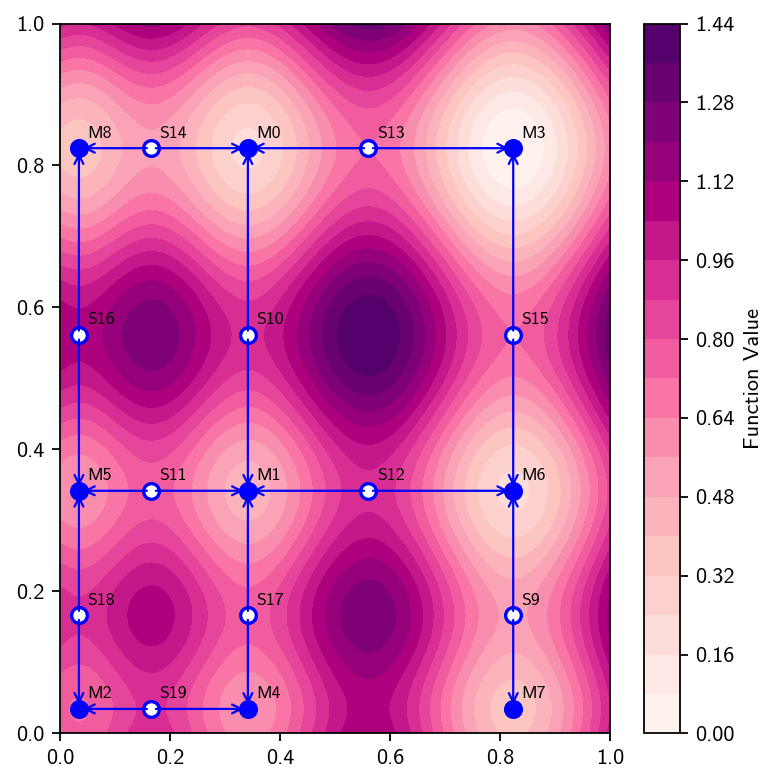

In [10]:
fig2 = plt.figure(figsize=(5,5), dpi=160)
fig2 = plot_results_with_paths(func=schwefel2D_numpy,  
                                critical_points_csv=critical_points_file,
                                saddle_to_minima_csv="results/saddle_to_minima_indices2D.csv",      
                                bounds=(0, 1),
                                res=200,
                                fig=fig2
)
fig2.show()
fig2.savefig("plots/landscape_paths.png")  # Optional

/tmp/ipykernel_156998/545800989.py:12: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig1.show()


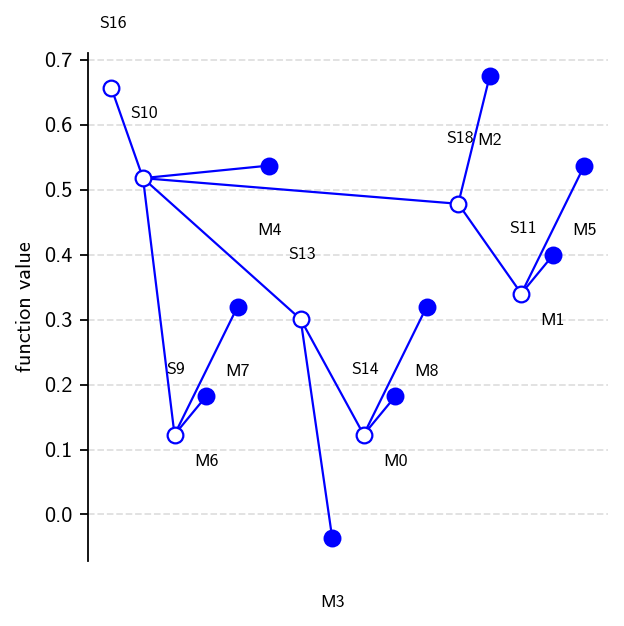

In [11]:
fig1 = plt.figure(figsize=(4,4), dpi=160)
fig1 = plot_saddle_tree_with_function(dataframe, 
                                      nodes_csv="results/tree_nodes.csv",
                                      edges_csv="results/tree_connectivity.csv", 
                                      fig=fig1)

ax = fig1.axes[0]
ax.set_ylabel("function value")
# ax.yaxis.set_major_locator(MaxNLocator(10))
fig1.tight_layout()

fig1.show()
fig1.savefig("plots/tree_plot.png")  # Optional